# 03k — E5 Official FreqBlender + SBI with EfficientNet-B4 Training

This notebook tests whether the authors' **official FreqBlender intervention** improves the generalisation-oriented E3d pipeline. It uses the same clean video split, source frames, official SBI generation, EfficientNet-B4 backbone, 380×380 detector input, optimiser, training budget and model-selection rule as E3d.

The sole intended change is that the authors' frozen FPNet modifies approximately **20% of dynamically generated SBI fake samples in DCT space**. FreqBlender is used only while generating synthetic training/validation fakes; it is not part of detector inference.


## Experimental design

- **Experiment:** E5 — Official FreqBlender + SBI with EfficientNet-B4
- **Research question:** Does adding the authors' official FreqBlender intervention to the E3d SBI-generation pipeline improve detection of genuine FF++ manipulations and unseen Celeb-DF deepfakes?
- **Hypothesis:** Frequency-guided modification of a minority of SBI pseudo-fakes will diversify synthetic artefacts and reduce dependence on dataset-specific spatial blending cues.
- **Primary control:** E3d — EfficientNet-B4/380 with official SBI and no FreqBlender
- **Secondary practical benchmark:** E3b — EfficientNet-B0/224 with official SBI, currently the strongest cross-dataset model
- **Independent variable:** official FPNet/DCT FreqBlender modification applied with probability 0.20 to generated SBI fake samples
- **Controlled variables:** FF++ source-video split; 1,342 training and 290 validation source frames; official SBI logic; B4/380 detector; ImageNet initialisation; full fine-tuning; Adam; learning rate 1e-4; weight decay 1e-4; 10 epochs; effective batch size 16; seed 42; best validation ROC-AUC selection
- **Training labels:** real = 0; dynamically generated SBI/FreqBlender fake = 1
- **Evaluation:** genuine FF++ test first, then the fixed Celeb-DF pilot without retraining, adaptation or threshold tuning
- **Decision rule:** the hypothesis is supported only if E5 improves the matched E3d cross-dataset results, especially video ROC-AUC, macro F1 and fake recall, without a major internal collapse

The authors' `base.json` reports 200 epochs and batch size 32. Those values are recorded for provenance but are **not adopted**, because doing so would change several variables relative to E3d and prevent a controlled comparison.


## 1. Safety controls

Training is controlled by `RUN_TRAINING`. Set it to `True` only when intentionally training E5. Checkpoint replacement remains disabled while `ALLOW_CHECKPOINT_OVERWRITE = False`.

In [ ]:
RUN_TRAINING = True
ALLOW_CHECKPOINT_OVERWRITE = False

CHECKPOINT_NAME = "efficientnet_b4_freqblender_sbi_best.pth"
RESULTS_NAME = "efficientnet_b4_freqblender_sbi_training_results.json"
LOSS_PLOT_NAME = "efficientnet_b4_freqblender_sbi_loss.png"
ACCURACY_PLOT_NAME = "efficientnet_b4_freqblender_sbi_accuracy.png"
AUC_PLOT_NAME = "efficientnet_b4_freqblender_sbi_auc.png"

FREQBLENDER_PROBABILITY = 0.20
FREQBLENDER_WORKING_SIZE = 400

print("E5 training enabled:", RUN_TRAINING)
print("Allow checkpoint overwrite:", ALLOW_CHECKPOINT_OVERWRITE)
print("E5 checkpoint:", CHECKPOINT_NAME)
print("Official FreqBlender probability:", FREQBLENDER_PROBABILITY)


E5 training enabled: True
Allow checkpoint overwrite: False
E5 checkpoint: efficientnet_b4_freqblender_sbi_best.pth
Official FreqBlender probability: 0.2


## 2. Mount Drive and validate project paths

This cell mounts Google Drive, resolves the existing prepared SBI data and protects any previous E3d checkpoint. It does not rebuild or modify the dataset.

In [ ]:
from google.colab import drive
from pathlib import Path
import torch

drive.mount("/content/drive")

BASE_PATH = Path("/content/drive/MyDrive/deepfake_project")
SBI_BASE = BASE_PATH / "sbi_dataset"
SPLIT_MANIFEST_PATH = BASE_PATH / "ffpp_video_split_manifest.json"
MODEL_DIR = BASE_PATH / "saved_models"
RESULTS_DIR = BASE_PATH / "results"
PLOTS_DIR = BASE_PATH / "plots"
ASSET_DIR = BASE_PATH / "external_assets" / "freqblender_official"
FPNET_CHECKPOINT_PATH = ASSET_DIR / "FreqBlender.tar"
AUTHOR_SBI_PATCH_PATH = ASSET_DIR / "sbi.py"
AUTHOR_BASE_CONFIG_PATH = ASSET_DIR / "base.json"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / CHECKPOINT_NAME
RESULTS_PATH = RESULTS_DIR / RESULTS_NAME

assert SBI_BASE.is_dir(), f"Prepared SBI dataset not found: {SBI_BASE}"
assert SPLIT_MANIFEST_PATH.is_file(), f"Split manifest not found: {SPLIT_MANIFEST_PATH}"

required_assets = {
    "FPNet checkpoint": FPNET_CHECKPOINT_PATH,
    "author sbi.py": AUTHOR_SBI_PATCH_PATH,
    "author base.json": AUTHOR_BASE_CONFIG_PATH,
}
missing_assets = [name for name, path in required_assets.items() if not path.is_file()]
if missing_assets:
    raise FileNotFoundError(
        "Missing official FreqBlender assets: " + ", ".join(missing_assets)
        + ". Place them in " + str(ASSET_DIR)
    )

if RUN_TRAINING and MODEL_PATH.exists() and not ALLOW_CHECKPOINT_OVERWRITE:
    raise FileExistsError(
        f"Checkpoint already exists: {MODEL_PATH}. Set ALLOW_CHECKPOINT_OVERWRITE = True only if replacement is intentional."
    )

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("SBI data:", SBI_BASE)
print("Checkpoint:", MODEL_PATH)
print("Official asset folder:", ASSET_DIR)
print("FPNet checkpoint:", FPNET_CHECKPOINT_PATH)
print("Split manifest:", SPLIT_MANIFEST_PATH)


Mounted at /content/drive
Device: cuda
GPU: Tesla T4
SBI data: /content/drive/MyDrive/deepfake_project/sbi_dataset
Checkpoint: /content/drive/MyDrive/deepfake_project/saved_models/efficientnet_b4_freqblender_sbi_best.pth
Official asset folder: /content/drive/MyDrive/deepfake_project/external_assets/freqblender_official
FPNet checkpoint: /content/drive/MyDrive/deepfake_project/external_assets/freqblender_official/FreqBlender.tar
Split manifest: /content/drive/MyDrive/deepfake_project/ffpp_video_split_manifest.json


## 3. Restore official repositories and validate author assets

The notebook restores clean public copies of SBI and FreqBlender. The supplied `sbi.py`, `base.json` and FPNet checkpoint remain in the project's external-assets folder and are hashed for provenance. The detector checkpoint is saved separately in `saved_models`.


In [ ]:
import hashlib
import json
import os
import subprocess
from pathlib import Path

subprocess.run(
    ["pip", "install", "-q", "torch-dct"],
    check=True,
)

OFFICIAL_REPOSITORY = "/content/SelfBlendedImages"
FREQBLENDER_REPOSITORY = "/content/FreqBlender_official"

repositories = [
    (
        "https://github.com/mapooon/SelfBlendedImages.git",
        OFFICIAL_REPOSITORY,
    ),
    (
        "https://github.com/OUC-VAS/FreqBlender.git",
        FREQBLENDER_REPOSITORY,
    ),
]

for repository_url, destination in repositories:
    if not os.path.isdir(destination):
        subprocess.run(
            ["git", "clone", repository_url, destination],
            check=True,
        )
        print("Restored:", destination)
    else:
        print("Already available:", destination)


def sha256(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        while chunk := handle.read(chunk_size):
            digest.update(chunk)
    return digest.hexdigest()


AUTHOR_ASSET_HASHES = {
    name: sha256(path)
    for name, path in required_assets.items()
}

EXPECTED_SBI_PATCH_SHA256 = "102da52ebc15b1ed4364bdc80d55a007032ec716af117e6114538a8a870b9401"
EXPECTED_BASE_CONFIG_SHA256 = "68fa242ec03ddef9381c988395ac4f492e12c688c75746d6c7103d8b8713633f"
EXPECTED_FPNET_SHA256 = "c42a4be0f642811f6db6f9c4aeb0f4f886b17ceb19b03ac9d194dc46d3f74a17"

assert AUTHOR_ASSET_HASHES["author sbi.py"] == EXPECTED_SBI_PATCH_SHA256, "Unexpected author sbi.py hash."
assert AUTHOR_ASSET_HASHES["author base.json"] == EXPECTED_BASE_CONFIG_SHA256, "Unexpected author base.json hash."
assert AUTHOR_ASSET_HASHES["FPNet checkpoint"] == EXPECTED_FPNET_SHA256, "Unexpected FPNet checkpoint hash."

with AUTHOR_BASE_CONFIG_PATH.open("r", encoding="utf-8") as handle:
    AUTHOR_BASE_CONFIG = json.load(handle)

print("Official asset SHA-256 hashes:")
for name, value in AUTHOR_ASSET_HASHES.items():
    print(f"  {name}: {value}")
print("Author base.json:", AUTHOR_BASE_CONFIG)
print("PASS: official assets are complete and match the verified copies.")


Restored: /content/SelfBlendedImages
Restored: /content/FreqBlender_official
Official asset SHA-256 hashes:
  FPNet checkpoint: c42a4be0f642811f6db6f9c4aeb0f4f886b17ceb19b03ac9d194dc46d3f74a17
  author sbi.py: 102da52ebc15b1ed4364bdc80d55a007032ec716af117e6114538a8a870b9401
  author base.json: 68fa242ec03ddef9381c988395ac4f492e12c688c75746d6c7103d8b8713633f
Author base.json: {'epoch': 200, 'batch_size': 32, 'image_size': 380}
PASS: official assets are complete and match the verified copies.


## 4. Audit SBI metadata against the clean video split

E3d must use exactly the same complete FF++ real-frame, RetinaFace and landmark triplets used by E3b. This audit checks membership, counts and zero train/validation video overlap.

In [ ]:
import json
import pandas as pd

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

with SPLIT_MANIFEST_PATH.open("r", encoding="utf-8") as handle:
    split_manifest = json.load(handle)

expected_counts = {"train": 1342, "val": 290}
audit_rows = []
observed_videos = {}

for split in ("train", "val"):
    frames_root = SBI_BASE / split / "frames" / "real"
    retina_root = SBI_BASE / split / "retina" / "real"
    landmarks_root = SBI_BASE / split / "landmarks" / "real"
    for required in (frames_root, retina_root, landmarks_root):
        assert required.is_dir(), f"Required SBI folder not found: {required}"

    complete_triplets = 0
    video_names = set()
    for video_folder in sorted(path for path in frames_root.iterdir() if path.is_dir()):
        video_names.add(video_folder.name)
        for frame_path in video_folder.iterdir():
            if frame_path.is_file() and frame_path.suffix.lower() in IMAGE_EXTENSIONS:
                retina_path = retina_root / video_folder.name / f"{frame_path.stem}.npy"
                landmark_path = landmarks_root / video_folder.name / f"{frame_path.stem}.npy"
                complete_triplets += int(retina_path.is_file() and landmark_path.is_file())

    expected_videos = {Path(name).stem for name in split_manifest["classes"]["real"][split]}
    assert video_names == expected_videos, (
        f"{split} SBI video folders do not exactly match the saved manifest. "
        f"Missing: {sorted(expected_videos - video_names)[:5]}; "
        f"unexpected: {sorted(video_names - expected_videos)[:5]}"
    )
    assert complete_triplets == expected_counts[split], (
        f"Expected {expected_counts[split]} complete {split} triplets, found {complete_triplets}."
    )
    observed_videos[split] = video_names
    audit_rows.append({
        "split": split,
        "complete_triplets": complete_triplets,
        "source_videos": len(video_names),
        "expected_triplets": expected_counts[split],
    })

overlap = observed_videos["train"] & observed_videos["val"]
assert not overlap, f"Train/validation video leakage detected: {sorted(overlap)[:5]}"

display(pd.DataFrame(audit_rows))
print("PASS: E3d uses complete SBI metadata from the clean video-level split.")


,split,complete_triplets,source_videos,expected_triplets
0,train,1342,140,1342
1,val,290,30,290


PASS: E3d uses complete SBI metadata from the clean video-level split.


## 5. Official SBI generation with the authors' FreqBlender intervention


Official SBI helper functions imported successfully.
FPNet parameters: 20,142,732
FPNet checkpoint epoch: 39
PASS: official FPNet checkpoint loaded with strict=True and frozen.
PASS: FPNet accepts 400x400 DCT tensors, returns three finite single-channel masks, and the masks broadcast correctly across RGB channels.
Official SBI train source frames: 1342
Official SBI val source frames: 290

E5 FreqBlender/SBI batch shape: torch.Size([8, 3, 380, 380])
Official SBI label shape: torch.Size([8])
Labels: [0, 0, 0, 0, 1, 1, 1, 1]


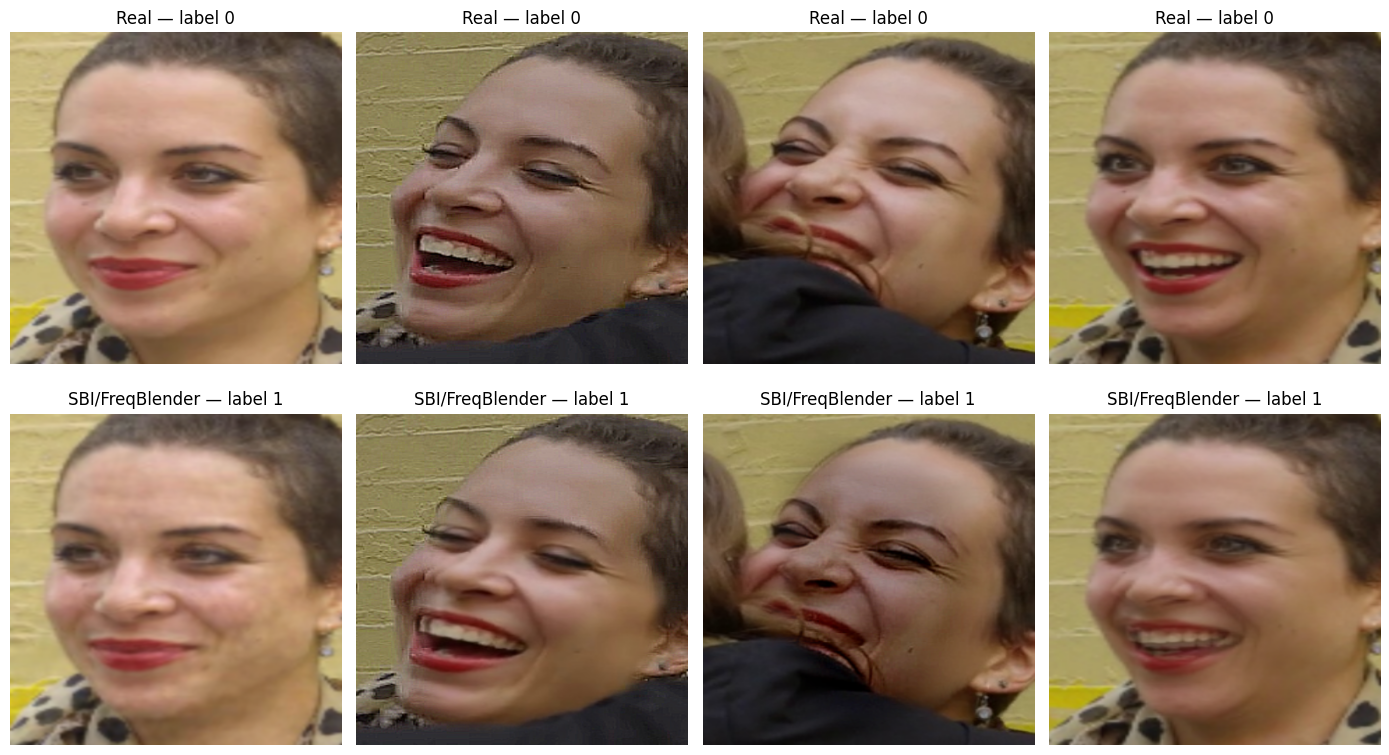

Preview generation counters — pairs: 4 FreqBlender-applied: 1
Note: the exact 20% frequency is probabilistic; deterministic validation seeds make the selected validation subset reproducible.


In [ ]:
# ============================================================
# E5: Official FreqBlender + SBI Fake Generation on Our Dataset
#
# Uses OUR existing preprocessed dataset:
#   sbi_dataset/<split>/frames/real/
#   sbi_dataset/<split>/retina/real/
#   sbi_dataset/<split>/landmarks/real/
#
# Uses OFFICIAL SBI generation logic:
#   - official crop_face()
#   - official IoU face matching
#   - official landmark reordering and horizontal flip
#   - official source transforms
#   - official affine + elastic mask transformation
#   - official dynamic blending
#   - official paired post-blending augmentation
#
# No files are deleted or generated permanently.
# Synthetic images are created dynamically in memory.
# The authors' frozen FPNet modifies 20% of generated fake samples in DCT space.
# ============================================================

import os
import sys
import cv2
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
import albumentations as alb
import importlib.util

from torch_dct import dct_2d, idct_2d

from PIL import Image
from torch.utils.data import Dataset, DataLoader


# ------------------------------------------------------------
# Paths and reproducibility
# ------------------------------------------------------------

base_path = "/content/drive/MyDrive/deepfake_project"
sbi_base = os.path.join(base_path, "sbi_dataset")

official_repo = "/content/SelfBlendedImages"
official_src = os.path.join(official_repo, "src")

if not os.path.exists(official_repo):
    raise RuntimeError(
        "Official SBI repository is missing from /content. "
        "Clone or restore SelfBlendedImages after restarting Colab."
    )

if official_src not in sys.path:
    sys.path.insert(0, official_src)

RANDOM_SEED = 42
IMAGE_SIZE = 380

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)


# ------------------------------------------------------------
# Import official SBI helper implementations
# ------------------------------------------------------------

from utils import blend as official_blend
from utils.funcs import (
    IoUfrom2bboxes,
    crop_face,
    RandomDownScale
)

print("Official SBI helper functions imported successfully.")


# ------------------------------------------------------------
# Load the public FPNet architecture and official checkpoint
# ------------------------------------------------------------

fpnet_architecture_path = os.path.join(
    FREQBLENDER_REPOSITORY,
    "net",
    "aeNet",
    "conv_autoencoder_pixelshuffle.py",
)
assert os.path.isfile(fpnet_architecture_path), (
    "Official FPNet architecture not found: " + fpnet_architecture_path
)

spec = importlib.util.spec_from_file_location(
    "official_freqblender_fpnet",
    fpnet_architecture_path,
)
fpnet_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(fpnet_module)

fpnet_checkpoint = torch.load(
    FPNET_CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False,
)
if not isinstance(fpnet_checkpoint, dict) or not isinstance(fpnet_checkpoint.get("model"), dict):
    raise TypeError("Official FPNet checkpoint must contain a 'model' state dictionary.")

fpnet_state = {
    key.removeprefix("module."): value
    for key, value in fpnet_checkpoint["model"].items()
}

FPNET_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
fpnet = fpnet_module.conv_autoencoder()
load_result = fpnet.load_state_dict(fpnet_state, strict=True)
fpnet = fpnet.to(FPNET_DEVICE).eval()
for parameter in fpnet.parameters():
    parameter.requires_grad = False

assert not load_result.missing_keys
assert not load_result.unexpected_keys
print("FPNet parameters:", f"{sum(p.numel() for p in fpnet.parameters()):,}")
print("FPNet checkpoint epoch:", fpnet_checkpoint.get("epoch", "not recorded"))
print("PASS: official FPNet checkpoint loaded with strict=True and frozen.")

with torch.inference_mode():
    fpnet_test_input = torch.zeros(
        1, 3, FREQBLENDER_WORKING_SIZE, FREQBLENDER_WORKING_SIZE,
        device=FPNET_DEVICE,
    )
    fpnet_test_output = fpnet(fpnet_test_input)
assert isinstance(fpnet_test_output, (tuple, list)) and len(fpnet_test_output) == 3

expected_mask_shape = (
    fpnet_test_input.shape[0],
    1,
    fpnet_test_input.shape[2],
    fpnet_test_input.shape[3],
)

assert all(
    tuple(item.shape) == expected_mask_shape
    for item in fpnet_test_output
), [tuple(item.shape) for item in fpnet_test_output]

assert all(
    torch.isfinite(item).all().item()
    for item in fpnet_test_output
)

# The authors' single-channel masks are broadcast across RGB DCT channels.
for item in fpnet_test_output:
    broadcast_test = fpnet_test_input * item
    assert tuple(broadcast_test.shape) == tuple(fpnet_test_input.shape)

print(
    "PASS: FPNet accepts 400x400 DCT tensors, returns three finite "
    "single-channel masks, and the masks broadcast correctly across RGB channels."
)


# ------------------------------------------------------------
# Albumentations compatibility helpers
#
# The official repository was written for an older version of
# Albumentations. These wrappers preserve the same parameters
# while supporting current Colab versions.
# ------------------------------------------------------------

def make_image_compression():
    import inspect

    parameters = inspect.signature(
        alb.ImageCompression.__init__
    ).parameters

    if "quality_range" in parameters:
        return alb.ImageCompression(
            quality_range=(40, 100),
            p=0.5
        )

    return alb.ImageCompression(
        quality_lower=40,
        quality_upper=100,
        p=0.5
    )


def make_elastic_transform():
    import inspect

    parameters = inspect.signature(
        alb.ElasticTransform.__init__
    ).parameters

    arguments = {
        "alpha": 50,
        "sigma": 7,
        "p": 1,
    }

    # The official legacy configuration used alpha_affine=0.
    # New releases removed this no-op argument.
    if "alpha_affine" in parameters:
        arguments["alpha_affine"] = 0

    return alb.ElasticTransform(**arguments)


# ------------------------------------------------------------
# Official-style SBI Dataset adapted only to our file paths
# ------------------------------------------------------------

class OfficialSBIDatasetFromOurData(Dataset):

    def __init__(
        self,
        root_path,
        phase="train",
        image_size=380
    ):
        assert phase in ["train", "val"]

        self.root_path = root_path
        self.phase = phase
        self.image_size = (
            image_size,
            image_size
        )

        self.frames_root = os.path.join(
            root_path,
            phase,
            "frames",
            "real"
        )

        self.retina_root = os.path.join(
            root_path,
            phase,
            "retina",
            "real"
        )

        self.landmarks_root = os.path.join(
            root_path,
            phase,
            "landmarks",
            "real"
        )

        self.samples = []

        for video_name in sorted(
            os.listdir(self.frames_root)
        ):
            frame_folder = os.path.join(
                self.frames_root,
                video_name
            )

            if not os.path.isdir(frame_folder):
                continue

            for frame_file in sorted(
                os.listdir(frame_folder)
            ):
                if not frame_file.lower().endswith(
                    ".png"
                ):
                    continue

                stem = os.path.splitext(
                    frame_file
                )[0]

                frame_path = os.path.join(
                    frame_folder,
                    frame_file
                )

                retina_path = os.path.join(
                    self.retina_root,
                    video_name,
                    stem + ".npy"
                )

                landmark_path = os.path.join(
                    self.landmarks_root,
                    video_name,
                    stem + ".npy"
                )

                if (
                    os.path.exists(frame_path)
                    and os.path.exists(retina_path)
                    and os.path.exists(landmark_path)
                ):
                    self.samples.append({
                        "frame": frame_path,
                        "retina": retina_path,
                        "landmarks": landmark_path
                    })

        self.transforms = self.get_transforms()
        self.source_transforms = (
            self.get_source_transforms()
        )
        self.freqblender_probability = FREQBLENDER_PROBABILITY
        self.freqblender_working_size = FREQBLENDER_WORKING_SIZE
        self.generated_pairs = 0
        self.freqblender_pairs = 0

        print(
            f"Official SBI {phase} source frames:",
            len(self.samples)
        )

    def __len__(self):
        return len(self.samples)

    # --------------------------------------------------------
    # Official SBI source transformation
    # --------------------------------------------------------

    def get_source_transforms(self):
        return alb.Compose([
            alb.Compose([
                alb.RGBShift(
                    r_shift_limit=(-20, 20),
                    g_shift_limit=(-20, 20),
                    b_shift_limit=(-20, 20),
                    p=0.3
                ),

                alb.HueSaturationValue(
                    hue_shift_limit=(-0.3, 0.3),
                    sat_shift_limit=(-0.3, 0.3),
                    val_shift_limit=(-0.3, 0.3),
                    p=1
                ),

                alb.RandomBrightnessContrast(
                    brightness_limit=(-0.1, 0.1),
                    contrast_limit=(-0.1, 0.1),
                    p=1
                ),
            ], p=1),

            alb.OneOf([
                RandomDownScale(p=1),

                alb.Sharpen(
                    alpha=(0.2, 0.5),
                    lightness=(0.5, 1.0),
                    p=1
                ),
            ], p=1),
        ], p=1)

    # --------------------------------------------------------
    # Official paired transformation
    #
    # The same random post-blending changes are applied to both
    # the real and generated fake image.
    # --------------------------------------------------------

    def get_transforms(self):
        return alb.Compose([
            alb.RGBShift(
                r_shift_limit=(-20, 20),
                g_shift_limit=(-20, 20),
                b_shift_limit=(-20, 20),
                p=0.3
            ),

            alb.HueSaturationValue(
                hue_shift_limit=(-0.3, 0.3),
                sat_shift_limit=(-0.3, 0.3),
                val_shift_limit=(-0.3, 0.3),
                p=0.3
            ),

            alb.RandomBrightnessContrast(
                brightness_limit=(-0.3, 0.3),
                contrast_limit=(-0.3, 0.3),
                p=0.3
            ),

            make_image_compression(),
        ],
        additional_targets={
            "image1": "image"
        },
        p=1)

    # --------------------------------------------------------
    # Official affine and elastic transformation
    # --------------------------------------------------------

    def randaffine(
        self,
        image,
        mask
    ):
        affine_transform = alb.Affine(
            translate_percent={
                "x": (-0.03, 0.03),
                "y": (-0.015, 0.015)
            },
            scale=(0.95, 1 / 0.95),
            fit_output=False,
            p=1
        )

        elastic_transform = (
            make_elastic_transform()
        )

        transformed = affine_transform(
            image=image,
            mask=mask
        )

        image = transformed["image"]
        mask = transformed["mask"]

        transformed = elastic_transform(
            image=image,
            mask=mask
        )

        mask = transformed["mask"]

        return image, mask

    # --------------------------------------------------------
    # Official landmark ordering
    # --------------------------------------------------------

    def reorder_landmark(
        self,
        landmark
    ):
        landmark = landmark.copy()

        landmark_add = np.zeros(
            (13, 2),
            dtype=landmark.dtype
        )

        official_order = [
            77, 75, 76, 68, 69, 70, 71,
            80, 72, 73, 79, 74, 78
        ]

        for new_index, old_index in enumerate(
            official_order
        ):
            landmark_add[new_index] = (
                landmark[old_index]
            )

        landmark[68:] = landmark_add

        return landmark

    # --------------------------------------------------------
    # Official horizontal flip
    #
    # This mirrors coordinates and reorders anatomical indices.
    # --------------------------------------------------------

    def hflip(
        self,
        image,
        mask=None,
        landmark=None,
        bbox=None
    ):
        height, width = image.shape[:2]

        landmark_new = None
        bbox_new = None

        if landmark is not None:
            landmark = landmark.copy()
            landmark_new = np.zeros_like(
                landmark
            )

            landmark_new[:17] = (
                landmark[:17][::-1]
            )

            landmark_new[17:27] = (
                landmark[17:27][::-1]
            )

            landmark_new[27:31] = (
                landmark[27:31]
            )

            landmark_new[31:36] = (
                landmark[31:36][::-1]
            )

            landmark_new[36:40] = (
                landmark[42:46][::-1]
            )

            landmark_new[40:42] = (
                landmark[46:48][::-1]
            )

            landmark_new[42:46] = (
                landmark[36:40][::-1]
            )

            landmark_new[46:48] = (
                landmark[40:42][::-1]
            )

            landmark_new[48:55] = (
                landmark[48:55][::-1]
            )

            landmark_new[55:60] = (
                landmark[55:60][::-1]
            )

            landmark_new[60:65] = (
                landmark[60:65][::-1]
            )

            landmark_new[65:68] = (
                landmark[65:68][::-1]
            )

            if len(landmark) == 81:
                landmark_new[68:81] = (
                    landmark[68:81][::-1]
                )

            elif len(landmark) != 68:
                raise NotImplementedError(
                    "Expected 68 or 81 landmarks."
                )

            landmark_new[:, 0] = (
                width - landmark_new[:, 0]
            )

        if bbox is not None:
            bbox = bbox.copy()
            bbox_new = np.zeros_like(bbox)

            bbox_new[0, 0] = bbox[1, 0]
            bbox_new[1, 0] = bbox[0, 0]

            bbox_new[:, 0] = (
                width - bbox_new[:, 0]
            )

            bbox_new[:, 1] = (
                bbox[:, 1].copy()
            )

            if len(bbox) > 2:
                bbox_new[2, 0] = (
                    width - bbox[3, 0]
                )
                bbox_new[2, 1] = bbox[3, 1]

                bbox_new[3, 0] = (
                    width - bbox[2, 0]
                )
                bbox_new[3, 1] = bbox[2, 1]

                bbox_new[4, 0] = (
                    width - bbox[4, 0]
                )
                bbox_new[4, 1] = bbox[4, 1]

                bbox_new[5, 0] = (
                    width - bbox[6, 0]
                )
                bbox_new[5, 1] = bbox[6, 1]

                bbox_new[6, 0] = (
                    width - bbox[5, 0]
                )
                bbox_new[6, 1] = bbox[5, 1]

        if mask is not None:
            mask = mask[:, ::-1]

        image = image[:, ::-1].copy()

        return (
            image,
            mask,
            landmark_new,
            bbox_new
        )

    # --------------------------------------------------------
    # Official self-blending logic
    #
    # Because the optional BI mask library is not included in
    # the public repository, this uses the official fallback:
    # cv2.convexHull over the dense landmarks.
    # --------------------------------------------------------

    def self_blending(
        self,
        image,
        landmark
    ):
        mask = np.zeros_like(
            image[:, :, 0],
            dtype=np.float32
        )

        if np.random.rand() < 0.25:
            landmark_for_mask = landmark[:68]
        else:
            landmark_for_mask = landmark

        cv2.fillConvexPoly(
            mask,
            cv2.convexHull(
                landmark_for_mask.astype(
                    np.int32
                )
            ),
            1.0
        )

        source = image.copy()
        target = image.copy()

        # Official code randomly transforms source or target.
        if np.random.rand() < 0.5:
            source = self.source_transforms(
                image=source.astype(np.uint8)
            )["image"]

        else:
            target = self.source_transforms(
                image=target.astype(np.uint8)
            )["image"]

        source, mask = self.randaffine(
            source,
            mask
        )

        blended, mask = (
            official_blend.dynamic_blend(
                source,
                target,
                mask
            )
        )

        blended = blended.astype(np.uint8)
        target = target.astype(np.uint8)

        return target, blended, mask

    # --------------------------------------------------------
    # Load and dynamically generate one official SBI pair
    # --------------------------------------------------------

    def _generate_pair(
        self,
        index
    ):
        sample = self.samples[index]

        image = np.array(
            Image.open(sample["frame"])
            .convert("RGB")
        )

        landmark_array = np.load(
            sample["landmarks"]
        )

        retina_array = np.load(
            sample["retina"]
        )

        landmark = (
            landmark_array[0]
            .astype(np.float32)
        )

        # Dense-landmark bounding rectangle
        bbox_landmark = np.array([
            landmark[:, 0].min(),
            landmark[:, 1].min(),
            landmark[:, 0].max(),
            landmark[:, 1].max()
        ])

        # Select RetinaFace box with highest IoU.
        maximum_iou = -1
        bbox = None

        for candidate in retina_array:
            candidate_iou = (
                IoUfrom2bboxes(
                    bbox_landmark,
                    candidate.flatten()[:4]
                )
            )

            if candidate_iou > maximum_iou:
                bbox = candidate.copy()
                maximum_iou = candidate_iou

        if bbox is None:
            raise RuntimeError(
                "No RetinaFace box matched landmarks."
            )

        landmark = self.reorder_landmark(
            landmark
        )

        # Official random training flip.
        if (
            self.phase == "train"
            and np.random.rand() < 0.5
        ):
            (
                image,
                _,
                landmark,
                bbox
            ) = self.hflip(
                image,
                None,
                landmark,
                bbox
            )

        # Official enlarged working crop.
        (
            image,
            landmark,
            bbox,
            _
        ) = crop_face(
            image,
            landmark,
            bbox,
            margin=True,
            crop_by_bbox=False,
            phase=self.phase
        )

        # Generate official SBI pair.
        image_real, image_fake, _ = (
            self.self_blending(
                image.copy(),
                landmark.copy()
            )
        )

        # Official paired post-blending augmentation.
        if self.phase == "train":
            transformed = self.transforms(
                image=image_fake.astype(
                    np.uint8
                ),
                image1=image_real.astype(
                    np.uint8
                )
            )

            image_fake = transformed["image"]
            image_real = transformed["image1"]

        # Official final crop from generated fake.
        (
            image_fake,
            _,
            _,
            _,
            y0,
            y1,
            x0,
            x1
        ) = crop_face(
            image_fake,
            landmark,
            bbox,
            margin=False,
            crop_by_bbox=True,
            abs_coord=True,
            phase=self.phase
        )

        # Apply identical coordinates to real image.
        image_real = image_real[
            y0:y1,
            x0:x1
        ]

        if (
            image_fake.size == 0
            or image_real.size == 0
        ):
            raise ValueError(
                "Official SBI created empty crop."
            )

        # Official SBI output is resized and divided by 255.
        image_fake = cv2.resize(
            image_fake,
            self.image_size,
            interpolation=cv2.INTER_LINEAR
        ).astype(np.float32) / 255.0

        image_real = cv2.resize(
            image_real,
            self.image_size,
            interpolation=cv2.INTER_LINEAR
        ).astype(np.float32) / 255.0

        # Exact intervention from the authors' patched sbi.py:
        # apply frozen FPNet to DCT maps for 20% of generated fakes.
        self.generated_pairs += 1
        if np.random.rand() < self.freqblender_probability:
            working_size = (
                self.freqblender_working_size,
                self.freqblender_working_size,
            )
            fake_400 = cv2.resize(image_fake, working_size)
            real_400 = cv2.resize(image_real, working_size)

            real_dct = dct_2d(
                torch.tensor(real_400, dtype=torch.float32)
                .permute(2, 0, 1),
                norm="ortho",
            ).unsqueeze(0)
            fake_dct = dct_2d(
                torch.tensor(fake_400, dtype=torch.float32)
                .permute(2, 0, 1),
                norm="ortho",
            ).unsqueeze(0)

            with torch.inference_mode():
                mask1, mask2, mask3 = fpnet(
                    fake_dct.to(FPNET_DEVICE)
                )

            new_fake_dct = (
                real_dct * mask1.detach().cpu()
                + fake_dct * mask2.detach().cpu()
                + real_dct * mask3.detach().cpu()
            )
            new_fake = torch.clip(
                idct_2d(new_fake_dct, norm="ortho"),
                0,
                1,
            )[0]
            image_fake = cv2.resize(
                new_fake.numpy().transpose(1, 2, 0),
                self.image_size,
            ).astype(np.float32)
            image_real = cv2.resize(
                image_real,
                self.image_size,
            ).astype(np.float32)
            self.freqblender_pairs += 1

        image_fake = image_fake.transpose(
            2,
            0,
            1
        )

        image_real = image_real.transpose(
            2,
            0,
            1
        )

        return (
            torch.tensor(
                image_fake,
                dtype=torch.float32
            ),
            torch.tensor(
                image_real,
                dtype=torch.float32
            )
        )

    def __getitem__(
        self,
        index
    ):
        # Keep validation output deterministic.
        if self.phase == "val":
            python_state = random.getstate()
            numpy_state = np.random.get_state()

            random.seed(
                RANDOM_SEED + index
            )
            np.random.seed(
                RANDOM_SEED + index
            )

        try:
            fake_tensor, real_tensor = (
                self._generate_pair(index)
            )

        except Exception as error:
            replacement_index = random.randrange(
                len(self.samples)
            )

            print(
                f"Official SBI sample error at "
                f"index {index}: {error}. "
                f"Using replacement index "
                f"{replacement_index}."
            )

            fake_tensor, real_tensor = (
                self._generate_pair(
                    replacement_index
                )
            )

        if self.phase == "val":
            random.setstate(
                python_state
            )
            np.random.set_state(
                numpy_state
            )

        return fake_tensor, real_tensor


# ------------------------------------------------------------
# Official collate logic
# ------------------------------------------------------------

def official_sbi_collate_fn(batch):
    fake_images, real_images = zip(*batch)

    real_batch = torch.stack(
        real_images
    )

    fake_batch = torch.stack(
        fake_images
    )

    images = torch.cat(
        [
            real_batch,
            fake_batch
        ],
        dim=0
    )

    labels = torch.tensor(
        [0] * len(real_images)
        + [1] * len(fake_images),
        dtype=torch.long
    )

    return {
        "images": images,
        "labels": labels
    }


# ------------------------------------------------------------
# Create E5 loaders
# ------------------------------------------------------------

official_sbi_train_dataset = (
    OfficialSBIDatasetFromOurData(
        sbi_base,
        phase="train",
        image_size=IMAGE_SIZE
    )
)

official_sbi_val_dataset = (
    OfficialSBIDatasetFromOurData(
        sbi_base,
        phase="val",
        image_size=IMAGE_SIZE
    )
)

# Eight source frames produce:
# 8 real + 8 official SBI fake = 16 model inputs.
OFFICIAL_SBI_SOURCE_BATCH_SIZE = 4

official_sbi_train_loader = DataLoader(
    official_sbi_train_dataset,
    batch_size=OFFICIAL_SBI_SOURCE_BATCH_SIZE,
    shuffle=True,
    collate_fn=official_sbi_collate_fn,
    num_workers=0,
    pin_memory=True,
    drop_last=True
)

official_sbi_val_loader = DataLoader(
    official_sbi_val_dataset,
    batch_size=OFFICIAL_SBI_SOURCE_BATCH_SIZE,
    shuffle=False,
    collate_fn=official_sbi_collate_fn,
    num_workers=0,
    pin_memory=True
)


# ------------------------------------------------------------
# Sanity-check one official SBI batch
# ------------------------------------------------------------

official_batch = next(
    iter(official_sbi_train_loader)
)

print()
print(
    "E5 FreqBlender/SBI batch shape:",
    official_batch["images"].shape
)

print(
    "Official SBI label shape:",
    official_batch["labels"].shape
)

print(
    "Labels:",
    official_batch["labels"].tolist()
)


# ------------------------------------------------------------
# Display four deterministic validation real/official-SBI pairs
# ------------------------------------------------------------

official_preview_batch = next(
    iter(official_sbi_val_loader)
)

number_of_pairs = 4

plt.figure(figsize=(14, 8))

for pair_index in range(
    number_of_pairs
):
    real_image = (
        official_preview_batch["images"][
            pair_index
        ]
        .cpu()
        .numpy()
        .transpose(1, 2, 0)
    )

    fake_image = (
        official_preview_batch["images"][
            OFFICIAL_SBI_SOURCE_BATCH_SIZE
            + pair_index
        ]
        .cpu()
        .numpy()
        .transpose(1, 2, 0)
    )

    plt.subplot(
        2,
        number_of_pairs,
        pair_index + 1
    )

    plt.imshow(
        np.clip(real_image, 0, 1)
    )

    plt.title(
        "Real — label 0"
    )

    plt.axis("off")

    plt.subplot(
        2,
        number_of_pairs,
        number_of_pairs
        + pair_index
        + 1
    )

    plt.imshow(
        np.clip(fake_image, 0, 1)
    )

    plt.title(
        "SBI/FreqBlender — label 1"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

print(
    "Preview generation counters — pairs:",
    official_sbi_val_dataset.generated_pairs,
    "FreqBlender-applied:",
    official_sbi_val_dataset.freqblender_pairs,
)
print(
    "Note: the exact 20% frequency is probabilistic; deterministic validation seeds "
    "make the selected validation subset reproducible."
)


## 6. Train and save E5


Using device: cuda
GPU: Tesla T4
Real training source frames: 1342
Real validation source frames: 290
Source batch size: 4
Model micro-batch size: 8
Gradient accumulation steps: 2
Effective optimiser batch size: 16
Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 189MB/s]


Trainable parameters: 17,552,202
Epoch 1 Batch 0/335 Loss: 0.7134
Epoch 1 Batch 20/335 Loss: 0.6833
Epoch 1 Batch 40/335 Loss: 0.6978
Epoch 1 Batch 60/335 Loss: 0.6800
Epoch 1 Batch 80/335 Loss: 0.6882
Epoch 1 Batch 100/335 Loss: 0.6733
Epoch 1 Batch 120/335 Loss: 0.6840
Epoch 1 Batch 140/335 Loss: 0.6895
Epoch 1 Batch 160/335 Loss: 0.6598
Epoch 1 Batch 180/335 Loss: 0.6802
Epoch 1 Batch 200/335 Loss: 0.6770
Epoch 1 Batch 220/335 Loss: 0.6279
Epoch 1 Batch 240/335 Loss: 0.6382
Epoch 1 Batch 260/335 Loss: 0.5768
Epoch 1 Batch 280/335 Loss: 0.6207
Epoch 1 Batch 300/335 Loss: 0.6909
Epoch 1 Batch 320/335 Loss: 0.5685

Epoch [1/10]
Train Loss: 0.6595 | Train Acc: 62.43% | Train Precision: 62.72% | Train Recall: 62.43% | Train F1: 62.21% | Train AUC: 0.6883
Val Loss: 0.5302 | Val Acc: 80.34% | Val Precision: 80.35% | Val Recall: 80.34% | Val F1: 80.34% | Val AUC: 0.8859
Learning rate: 0.00010000
Epoch time: 71.83 minutes
*** Best E5 FreqBlender + SBI model updated at Epoch 1 | Val AUC: 0.88

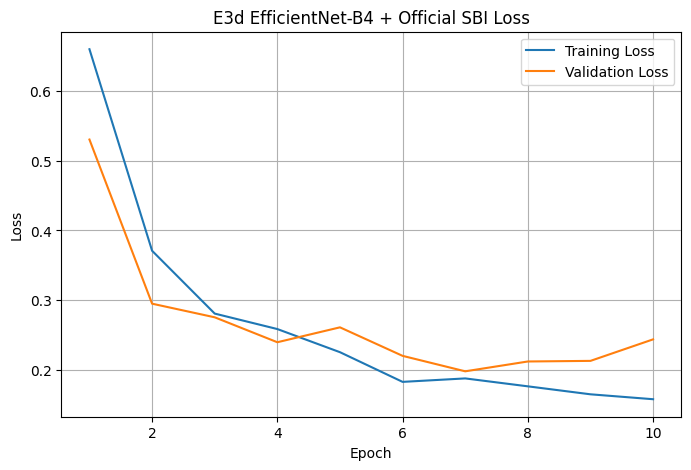

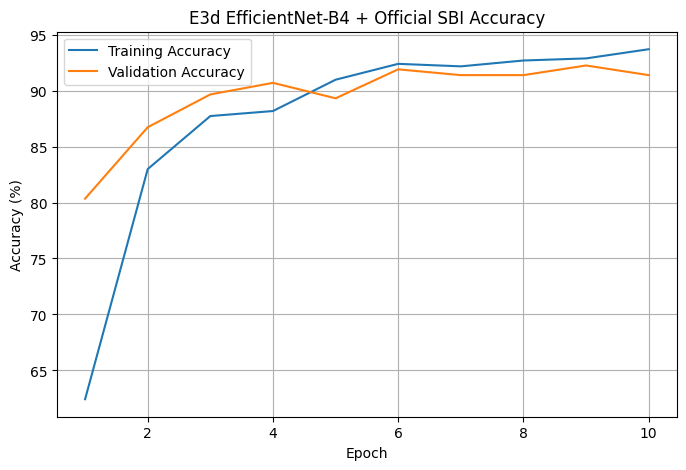

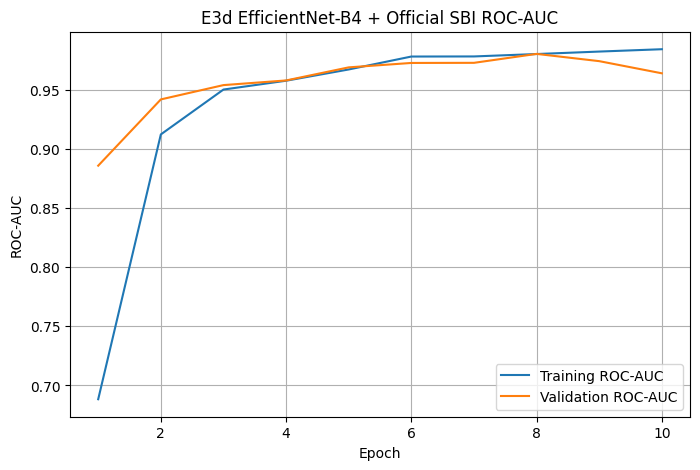

In [ ]:
# ============================================================
# E5: EfficientNet-B4 with Official FreqBlender + SBI
#
# Training source:
#   Real FF++ training frames only
#
# Dynamic training pairs:
#   Original real image -> label 0
#   Official SBI/FreqBlender fake -> label 1
#
# Validation:
#   Real validation frames + dynamically generated SBI fakes
#
# Backbone:
#   ImageNet-pretrained EfficientNet-B4
#   Full fine-tuning
#
# Model selection:
#   Best validation ROC-AUC
#
# Safety:
#   Does not overwrite E3b, E3c, E3d or E4 models/results.
# ============================================================

if RUN_TRAINING:
    import os
    import json
    import time
    import random
    import numpy as np
    import torch
    import torch.nn as nn
    import torch.optim as optim
    import matplotlib.pyplot as plt

    from torchvision.models import (
        efficientnet_b4,
        EfficientNet_B4_Weights
    )

    from sklearn.metrics import (
        accuracy_score,
        precision_score,
        recall_score,
        f1_score,
        roc_auc_score
    )

    # --------------------------------------------------------
    # Paths
    # --------------------------------------------------------

    base_path = "/content/drive/MyDrive/deepfake_project"

    model_dir = os.path.join(
        base_path,
        "saved_models"
    )

    results_dir = os.path.join(
        base_path,
        "results"
    )

    plots_dir = os.path.join(
        base_path,
        "plots"
    )

    os.makedirs(
        model_dir,
        exist_ok=True
    )

    os.makedirs(
        results_dir,
        exist_ok=True
    )

    os.makedirs(
        plots_dir,
        exist_ok=True
    )

    model_path = os.path.join(
        model_dir,
        CHECKPOINT_NAME
    )

    results_path = os.path.join(
        results_dir,
        RESULTS_NAME
    )

    # --------------------------------------------------------
    # Device
    # --------------------------------------------------------

    device = torch.device(
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )

    print("Using device:", device)

    if torch.cuda.is_available():
        print(
            "GPU:",
            torch.cuda.get_device_name(0)
        )

        torch.cuda.empty_cache()

    # --------------------------------------------------------
    # Confirm required loaders exist
    # --------------------------------------------------------

    required_objects = [
        "official_sbi_train_loader",
        "official_sbi_val_loader",
        "OFFICIAL_SBI_SOURCE_BATCH_SIZE"
    ]

    missing_objects = [
        name
        for name in required_objects
        if name not in globals()
    ]

    if missing_objects:
        raise RuntimeError(
            "Run the official SBI loader cell first. "
            f"Missing objects: {missing_objects}"
        )

    print(
        "Real training source frames:",
        len(official_sbi_train_loader.dataset)
    )

    print(
        "Real validation source frames:",
        len(official_sbi_val_loader.dataset)
    )

    print(
        "Source batch size:",
        OFFICIAL_SBI_SOURCE_BATCH_SIZE
    )

    print(
        "Model micro-batch size:",
        OFFICIAL_SBI_SOURCE_BATCH_SIZE * 2
    )

    # --------------------------------------------------------
    # Reproducibility
    # --------------------------------------------------------

    RANDOM_SEED = 42

    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    torch.manual_seed(RANDOM_SEED)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(
            RANDOM_SEED
        )

    # --------------------------------------------------------
    # Training configuration
    # --------------------------------------------------------

    NUM_EPOCHS = 10
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 1e-4
    GRADIENT_ACCUMULATION_STEPS = 2

    print(
        "Gradient accumulation steps:",
        GRADIENT_ACCUMULATION_STEPS
    )
    print(
        "Effective optimiser batch size:",
        OFFICIAL_SBI_SOURCE_BATCH_SIZE
        * 2
        * GRADIENT_ACCUMULATION_STEPS
    )

    # --------------------------------------------------------
    # Model
    # --------------------------------------------------------

    weights = EfficientNet_B4_Weights.DEFAULT

    model = efficientnet_b4(
        weights=weights
    )

    model.classifier[1] = nn.Linear(
        model.classifier[1].in_features,
        2
    )

    # Full fine-tuning:
    # no EfficientNet layers are frozen.
    for parameter in model.parameters():
        parameter.requires_grad = True

    model = model.to(device)

    trainable_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    print(
        "Trainable parameters:",
        f"{trainable_parameters:,}"
    )

    # --------------------------------------------------------
    # Loss, optimiser and scheduler
    # --------------------------------------------------------

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = (
        optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=0.5,
            patience=2
        )
    )

    # --------------------------------------------------------
    # Metric helper
    # --------------------------------------------------------

    def calculate_binary_metrics(
        labels,
        predictions,
        fake_probabilities
    ):
        accuracy = accuracy_score(
            labels,
            predictions
        ) * 100

        precision = precision_score(
            labels,
            predictions,
            average="macro",
            zero_division=0
        ) * 100

        recall = recall_score(
            labels,
            predictions,
            average="macro",
            zero_division=0
        ) * 100

        f1 = f1_score(
            labels,
            predictions,
            average="macro",
            zero_division=0
        ) * 100

        try:
            auc = roc_auc_score(
                labels,
                fake_probabilities
            )
        except ValueError:
            auc = None

        return {
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "roc_auc": auc
        }

    # --------------------------------------------------------
    # Training history
    # --------------------------------------------------------

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "train_precision": [],
        "train_recall": [],
        "train_f1": [],
        "train_roc_auc": [],

        "val_loss": [],
        "val_accuracy": [],
        "val_precision": [],
        "val_recall": [],
        "val_f1": [],
        "val_roc_auc": [],

        "learning_rate": []
    }

    best_val_auc = -1.0
    best_val_accuracy = 0.0
    best_val_f1 = 0.0
    best_epoch = 0

    training_start_time = time.time()

    # --------------------------------------------------------
    # Epoch loop
    # --------------------------------------------------------

    for epoch in range(NUM_EPOCHS):

        epoch_start_time = time.time()

        # ====================================================
        # Training phase
        # ====================================================

        model.train()

        running_train_loss = 0.0

        train_labels = []
        train_predictions = []
        train_probabilities = []

        optimizer.zero_grad(
            set_to_none=True
        )

        for batch_index, batch in enumerate(
            official_sbi_train_loader
        ):
            images = batch["images"].to(
                device,
                non_blocking=True
            )

            labels = batch["labels"].to(
                device,
                non_blocking=True
            )

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            scaled_loss = (
                loss
                / GRADIENT_ACCUMULATION_STEPS
            )
            scaled_loss.backward()

            accumulation_boundary = (
                (batch_index + 1)
                % GRADIENT_ACCUMULATION_STEPS
                == 0
                or batch_index + 1
                == len(official_sbi_train_loader)
            )

            if accumulation_boundary:
                optimizer.step()
                optimizer.zero_grad(
                    set_to_none=True
                )

            running_train_loss += (
                loss.item()
            )

            fake_probabilities = (
                torch.softmax(
                    outputs,
                    dim=1
                )[:, 1]
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            train_labels.extend(
                labels
                .detach()
                .cpu()
                .numpy()
                .tolist()
            )

            train_predictions.extend(
                predictions
                .detach()
                .cpu()
                .numpy()
                .tolist()
            )

            train_probabilities.extend(
                fake_probabilities
                .detach()
                .cpu()
                .numpy()
                .tolist()
            )

            if batch_index % 20 == 0:
                print(
                    f"Epoch {epoch + 1} "
                    f"Batch {batch_index}/"
                    f"{len(official_sbi_train_loader)} "
                    f"Loss: {loss.item():.4f}"
                )

        average_train_loss = (
            running_train_loss
            / len(official_sbi_train_loader)
        )

        train_metrics = (
            calculate_binary_metrics(
                train_labels,
                train_predictions,
                train_probabilities
            )
        )

        # ====================================================
        # Validation phase
        # ====================================================

        model.eval()

        running_val_loss = 0.0

        val_labels = []
        val_predictions = []
        val_probabilities = []

        with torch.no_grad():

            for batch in official_sbi_val_loader:
                images = batch["images"].to(
                    device,
                    non_blocking=True
                )

                labels = batch["labels"].to(
                    device,
                    non_blocking=True
                )

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

                running_val_loss += (
                    loss.item()
                )

                fake_probabilities = (
                    torch.softmax(
                        outputs,
                        dim=1
                    )[:, 1]
                )

                predictions = torch.argmax(
                    outputs,
                    dim=1
                )

                val_labels.extend(
                    labels
                    .detach()
                    .cpu()
                    .numpy()
                    .tolist()
                )

                val_predictions.extend(
                    predictions
                    .detach()
                    .cpu()
                    .numpy()
                    .tolist()
                )

                val_probabilities.extend(
                    fake_probabilities
                    .detach()
                    .cpu()
                    .numpy()
                    .tolist()
                )

        average_val_loss = (
            running_val_loss
            / len(official_sbi_val_loader)
        )

        val_metrics = (
            calculate_binary_metrics(
                val_labels,
                val_predictions,
                val_probabilities
            )
        )

        current_learning_rate = (
            optimizer.param_groups[0]["lr"]
        )

        scheduler_value = (
            val_metrics["roc_auc"]
            if val_metrics["roc_auc"]
            is not None
            else val_metrics["accuracy"] / 100
        )

        scheduler.step(
            scheduler_value
        )

        # ----------------------------------------------------
        # Save history
        # ----------------------------------------------------

        history["train_loss"].append(
            average_train_loss
        )

        history["train_accuracy"].append(
            train_metrics["accuracy"]
        )

        history["train_precision"].append(
            train_metrics["precision"]
        )

        history["train_recall"].append(
            train_metrics["recall"]
        )

        history["train_f1"].append(
            train_metrics["f1"]
        )

        history["train_roc_auc"].append(
            train_metrics["roc_auc"]
        )

        history["val_loss"].append(
            average_val_loss
        )

        history["val_accuracy"].append(
            val_metrics["accuracy"]
        )

        history["val_precision"].append(
            val_metrics["precision"]
        )

        history["val_recall"].append(
            val_metrics["recall"]
        )

        history["val_f1"].append(
            val_metrics["f1"]
        )

        history["val_roc_auc"].append(
            val_metrics["roc_auc"]
        )

        history["learning_rate"].append(
            current_learning_rate
        )

        epoch_time = (
            time.time()
            - epoch_start_time
        )

        # ----------------------------------------------------
        # Epoch logging
        # ----------------------------------------------------

        print()
        print(
            f"Epoch [{epoch + 1}/{NUM_EPOCHS}]"
        )

        print(
            f"Train Loss: "
            f"{average_train_loss:.4f} | "
            f"Train Acc: "
            f"{train_metrics['accuracy']:.2f}% | "
            f"Train Precision: "
            f"{train_metrics['precision']:.2f}% | "
            f"Train Recall: "
            f"{train_metrics['recall']:.2f}% | "
            f"Train F1: "
            f"{train_metrics['f1']:.2f}% | "
            f"Train AUC: "
            f"{train_metrics['roc_auc']:.4f}"
        )

        print(
            f"Val Loss: "
            f"{average_val_loss:.4f} | "
            f"Val Acc: "
            f"{val_metrics['accuracy']:.2f}% | "
            f"Val Precision: "
            f"{val_metrics['precision']:.2f}% | "
            f"Val Recall: "
            f"{val_metrics['recall']:.2f}% | "
            f"Val F1: "
            f"{val_metrics['f1']:.2f}% | "
            f"Val AUC: "
            f"{val_metrics['roc_auc']:.4f}"
        )

        print(
            "Learning rate:",
            f"{current_learning_rate:.8f}"
        )

        print(
            "Epoch time:",
            f"{epoch_time / 60:.2f} minutes"
        )

        # ----------------------------------------------------
        # Save checkpoint with best validation ROC-AUC
        # ----------------------------------------------------

        current_val_auc = (
            val_metrics["roc_auc"]
            if val_metrics["roc_auc"]
            is not None
            else -1.0
        )

        if current_val_auc > best_val_auc:

            best_val_auc = (
                current_val_auc
            )

            best_val_accuracy = (
                val_metrics["accuracy"]
            )

            best_val_f1 = (
                val_metrics["f1"]
            )

            best_epoch = epoch + 1

            checkpoint = {
                "experiment": "E5",

                "model_name":
                    "EfficientNet-B4 + Official FreqBlender + SBI",

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "epoch":
                    best_epoch,

                "best_val_auc":
                    best_val_auc,

                "best_val_accuracy":
                    best_val_accuracy,

                "best_val_f1":
                    best_val_f1,

                "learning_rate":
                    LEARNING_RATE,

                "weight_decay":
                    WEIGHT_DECAY,

                "source_batch_size":
                    OFFICIAL_SBI_SOURCE_BATCH_SIZE,

                "micro_batch_size":
                    OFFICIAL_SBI_SOURCE_BATCH_SIZE * 2,

                "gradient_accumulation_steps":
                    GRADIENT_ACCUMULATION_STEPS,

                "effective_batch_size":
                    OFFICIAL_SBI_SOURCE_BATCH_SIZE * 2 * GRADIENT_ACCUMULATION_STEPS,

                "classes": [
                    "real",
                    "fake"
                ],

                "preprocessing":
                    "resize 380x380; float32 / 255; no ImageNet normalisation",

                "split_unit":
                    "source_video",

                "seed":
                    RANDOM_SEED,

                "freqblender_probability": FREQBLENDER_PROBABILITY,
                "freqblender_working_size": FREQBLENDER_WORKING_SIZE,
                "fpnet_frozen": True,
                "author_asset_sha256": AUTHOR_ASSET_HASHES
            }

            torch.save(
                checkpoint,
                model_path
            )

            print(
                "*** Best E5 FreqBlender + SBI model "
                f"updated at Epoch {best_epoch} | "
                f"Val AUC: {best_val_auc:.4f} | "
                f"Val Accuracy: "
                f"{best_val_accuracy:.2f}% | "
                f"Val F1: {best_val_f1:.2f}% ***"
            )

        print("-" * 75)

    # --------------------------------------------------------
    # Training completed
    # --------------------------------------------------------

    total_training_time = (
        time.time()
        - training_start_time
    )

    training_results = {
        "experiment": "E5",

        "model":
            "EfficientNet-B4 + Official FreqBlender + SBI",

        "backbone":
            "EfficientNet-B4",

        "pretrained_on":
            "ImageNet",

        "fine_tuning":
            True,

        "backbone_frozen":
            False,

        "training_source":
            "Real FF++ training videos only",

        "genuine_fake_training_images_used":
            False,

        "synthetic_fake_generation":
            "Official SBI generation plus official frozen FPNet/DCT intervention",

        "epochs":
            NUM_EPOCHS,

        "source_batch_size":
            OFFICIAL_SBI_SOURCE_BATCH_SIZE,

        "micro_batch_size":
            OFFICIAL_SBI_SOURCE_BATCH_SIZE * 2,

        "gradient_accumulation_steps":
            GRADIENT_ACCUMULATION_STEPS,

        "effective_batch_size":
            OFFICIAL_SBI_SOURCE_BATCH_SIZE * 2 * GRADIENT_ACCUMULATION_STEPS,

        "learning_rate":
            LEARNING_RATE,

        "weight_decay":
            WEIGHT_DECAY,

        "optimizer":
            "Adam",

        "loss":
            "CrossEntropyLoss",

        "checkpoint_selection":
            "Best synthetic validation ROC-AUC",

        "validation_type":
            "deterministic real/SBI synthetic pairs with reproducible 20% FreqBlender selection",

        "preprocessing":
            "resize 380x380; float32 / 255; no ImageNet normalisation",

        "split_unit":
            "source_video",

        "seed":
            RANDOM_SEED,

        "freqblender_probability": FREQBLENDER_PROBABILITY,
        "freqblender_working_size": FREQBLENDER_WORKING_SIZE,
        "fpnet_frozen": True,
        "fpnet_used_at_inference": False,
        "author_base_config": AUTHOR_BASE_CONFIG,
        "author_asset_sha256": AUTHOR_ASSET_HASHES,

        "label_mapping": {
            "real": 0,
            "fake": 1
        },

        "best_epoch":
            best_epoch,

        "best_val_auc":
            best_val_auc,

        "best_val_accuracy":
            best_val_accuracy,

        "best_val_f1":
            best_val_f1,

        "final_train_loss":
            history["train_loss"][-1],

        "final_val_loss":
            history["val_loss"][-1],

        "total_training_time_minutes":
            round(
                total_training_time / 60,
                2
            ),

        "model_path":
            model_path,

        "history":
            history
    }

    with open(
        results_path,
        "w"
    ) as file:
        json.dump(
            training_results,
            file,
            indent=4
        )

    print()
    print("Official SBI training completed.")

    print(
        "Best Validation ROC-AUC:",
        f"{best_val_auc:.4f}"
    )

    print(
        "Validation Accuracy at Best AUC:",
        f"{best_val_accuracy:.2f}%"
    )

    print(
        "Validation F1 at Best AUC:",
        f"{best_val_f1:.2f}%"
    )

    print(
        "Best Epoch:",
        best_epoch
    )

    print(
        "Total training time:",
        f"{total_training_time / 60:.2f} minutes"
    )

    print(
        "Best model saved to:",
        model_path
    )

    print(
        "Training results saved to:",
        results_path
    )

    # --------------------------------------------------------
    # Plot loss
    # --------------------------------------------------------

    epochs = range(
        1,
        NUM_EPOCHS + 1
    )

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history["train_loss"],
        label="Training Loss"
    )

    plt.plot(
        epochs,
        history["val_loss"],
        label="Validation Loss"
    )

    plt.title(
        "E3d EfficientNet-B4 + Official SBI Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    loss_plot_path = os.path.join(
        plots_dir,
        LOSS_PLOT_NAME
    )

    plt.savefig(
        loss_plot_path,
        bbox_inches="tight"
    )

    plt.show()

    # --------------------------------------------------------
    # Plot accuracy
    # --------------------------------------------------------

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history["train_accuracy"],
        label="Training Accuracy"
    )

    plt.plot(
        epochs,
        history["val_accuracy"],
        label="Validation Accuracy"
    )

    plt.title(
        "E3d EfficientNet-B4 + Official SBI Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.legend()
    plt.grid(True)

    accuracy_plot_path = os.path.join(
        plots_dir,
        ACCURACY_PLOT_NAME
    )

    plt.savefig(
        accuracy_plot_path,
        bbox_inches="tight"
    )

    plt.show()

    # --------------------------------------------------------
    # Plot ROC-AUC
    # --------------------------------------------------------

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history["train_roc_auc"],
        label="Training ROC-AUC"
    )

    plt.plot(
        epochs,
        history["val_roc_auc"],
        label="Validation ROC-AUC"
    )

    plt.title(
        "E3d EfficientNet-B4 + Official SBI ROC-AUC"
    )

    plt.xlabel("Epoch")
    plt.ylabel("ROC-AUC")
    plt.legend()
    plt.grid(True)

    auc_plot_path = os.path.join(
        plots_dir,
        AUC_PLOT_NAME
    )

    plt.savefig(
        auc_plot_path,
        bbox_inches="tight"
    )

    plt.show()

else:
    print(
        "Official SBI training skipped. "
        "Set RUN_TRAINING = True."
    )


## 7. Next notebooks

After training, evaluate `efficientnet_b4_freqblender_sbi_best.pth` in two new modules:

1. `04k_E5_FreqBlender_B4_FFPP_Evaluation.ipynb` on the same genuine FF++ B4 face-crop subset used by E3d.
2. `05k_E5_FreqBlender_B4_CelebDF_Evaluation.ipynb` on the same fixed Celeb-DF B4 pilot used by E3d.

Inference preprocessing is **380×380 → float32 → divide by 255**, without ImageNet mean/std normalisation. Use threshold 0.5 and calculate frame- and video-level metrics. Do not generate SBI samples, load FPNet, apply DCT/FreqBlender, retrain, adapt or tune the threshold during either evaluation.
